# Comparaison CAE vs VAE — Version Corrigée
**Corrections apportées :**
- Triple split strict 70/20/10 avec normalisation calculée sur X_train uniquement (pas de data leakage)
- VAE avec `test_step` → EarlyStopping sur `val_loss` comme le CAE
- Reconstruction 1 minute filtrée par label (signal cohérent)
- Reconstruction affichée sur les 3 axes
- Inférence VAE cohérente avec l'entraînement (z échantillonné)

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import time

## 1. Chargement et fenêtrage

In [5]:
path = "D:/IMDS/MALMO/IMU_LM_Data/data/merged_dataset/filtered_activities_dataset.parquet"
df = pd.read_parquet(path)

features = ["acc_x", "acc_y", "acc_z"]
df = df[["timestamp_ns", "dataset", "subject_id", "session_id", "global_activity_id"] + features]

# Passage à 25Hz (1 ligne sur 2)
df = df.iloc[::2].copy()
df[features] = df[features].interpolate(method='linear').bfill().ffill()

# Fenêtrage (2 secondes = 50 points à 25Hz)
WINDOW_SIZE, STRIDE = 50, 25
X, labels = [], []

print("Création des fenêtres...")
for _, group in df.groupby(["dataset", "subject_id", "session_id"]):
    sig  = group[features].values
    acts = group["global_activity_id"].values
    for i in range(0, len(sig) - WINDOW_SIZE, STRIDE):
        X.append(sig[i:i + WINDOW_SIZE])
        labels.append(np.bincount(acts[i:i + WINDOW_SIZE]).argmax())

X      = np.array(X, dtype=np.float32)
labels = np.array(labels)
print(f"Dataset complet : {X.shape}  — {len(np.unique(labels))} labels uniques")

Création des fenêtres...
Dataset complet : (211039, 50, 3)  — 3 labels uniques


## 2. Triple split 70 / 20 / 10 + normalisation sans data leakage

**Correction clé :** la normalisation est calculée uniquement sur `X_train`,
puis appliquée à `X_val` et `X_test`. Avant, elle était calculée sur tout le
dataset (incluant le test set), ce qui constituait une fuite de données.

In [6]:
# --- Split AVANT normalisation ---
# Étape 1 : isoler les 10% de test final (jamais touchés pendant l'entraînement)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, labels, test_size=0.10, random_state=42, stratify=labels
)

# Étape 2 : dans les 90% restants, 22.22% → validation (≈ 20% du total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp
)

# --- Normalisation calculée UNIQUEMENT sur X_train ---
X_mean = np.mean(X_train, axis=(0, 1))   # shape (3,)
X_std  = np.std(X_train,  axis=(0, 1))   # shape (3,)

X_train = (X_train - X_mean) / (X_std + 1e-7)
X_val   = (X_val   - X_mean) / (X_std + 1e-7)   # mêmes paramètres
X_test  = (X_test  - X_mean) / (X_std + 1e-7)   # mêmes paramètres

print(f"Train : {len(X_train):>7} fenêtres")
print(f"Val   : {len(X_val):>7} fenêtres")
print(f"Test  : {len(X_test):>7} fenêtres")

Train :  147731 fenêtres
Val   :   42204 fenêtres
Test  :   21104 fenêtres


## 3. Hyperparamètres et architectures

In [7]:
timesteps  = 50
n_features = 3
latent_dim = 32
EPOCHS     = 150
BATCH_SIZE = 256
PATIENCE   = 8

# ---- Encodeur CAE ----
def get_encoder_cae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32,  5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)                                          # 50 → 25
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)                                          # 25 → 12
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    latent = layers.Dense(latent_dim, name="cae_latent")(x)
    return Model(inputs, latent, name="Encoder_CAE")

# ---- Encodeur VAE (produit z_mean et z_log_var) ----
def get_encoder_vae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32,  5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    return Model(inputs, [z_mean, z_log_var], name="Encoder_VAE")

# ---- Décodeur commun (même architecture pour CAE et VAE) ----
def get_decoder(name):
    inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(12 * 128, activation='relu')(inputs)
    x = layers.Reshape((12, 128))(x)
    x = layers.UpSampling1D(2)(x)                                          # 12 → 24
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)                                          # 24 → 48
    x = layers.ZeroPadding1D(padding=(1, 1))(x)                            # 48 → 50
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    outputs = layers.Conv1D(n_features, 5, activation='linear', padding='same')(x)
    return Model(inputs, outputs, name=name)

## 4. Entraînement CAE

In [8]:
print("--- ENTRAÎNEMENT CAE ---")
cae_encoder = get_encoder_cae()
cae_decoder = get_decoder("Decoder_CAE")
cae_model   = Model(cae_encoder.input, cae_decoder(cae_encoder.output))

cae_model.compile(optimizer='adam', loss='mse')

t0 = time.time()
history_cae = cae_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),   # X_val pour EarlyStopping
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)
time_cae = time.time() - t0
print(f"CAE entraîné en {time_cae:.1f}s")

--- ENTRAÎNEMENT CAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - loss: 0.1053 - val_loss: 0.0610
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 0.0560 - val_loss: 0.0518
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - loss: 0.0505 - val_loss: 0.0492
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - loss: 0.0482 - val_loss: 0.0479
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - loss: 0.0469 - val_loss: 0.0489
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - loss: 0.0461 - val_loss: 0.0466
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 0.0456 - val_loss: 0.0443
Epoch 8/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - loss: 0.0447 - val_loss: 0.0437
Epoch 9/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 0.0432 - val_loss: 0.0418
Epoch 10/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - loss: 0.0425 - val_loss: 0.0418
Epoch 11/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 0.0411 - val_loss: 0

## 5. Entraînement VAE

**Correction clé :** ajout de `test_step` dans `BetaVAE` pour que Keras puisse
calculer la `val_loss` à chaque époque. Sans ça, `validation_data` était ignoré
et l'EarlyStopping monitorait la loss d'entraînement — le modèle pouvait overfitter.

In [9]:
class BetaVAE(Model):
    def __init__(self, encoder, decoder, beta=0.01, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon")
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_loss(self, data):
        """Calcul partagé entre train_step et test_step."""
        zm, zv = self.encoder(data)
        # Reparameterization trick (sampling réduit à 0.1 pour stabilité)
        z     = zm + 0.1 * tf.exp(0.5 * zv) * tf.random.normal(tf.shape(zm))
        recon = self.decoder(z)
        r_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(data, recon), axis=-1))
        kl_loss = -0.5 * tf.reduce_mean(1 + zv - tf.square(zm) - tf.exp(zv))
        total   = r_loss + self.beta * kl_loss
        return total, r_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total, r_loss, kl_loss = self._compute_loss(data)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    # --- CORRECTION : test_step pour que val_loss soit calculée ---
    def test_step(self, data):
        total, r_loss, kl_loss = self._compute_loss(data)
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


print("--- ENTRAÎNEMENT VAE ---")
vae_enc   = get_encoder_vae()
vae_dec   = get_decoder("Decoder_VAE")
vae_model = BetaVAE(vae_enc, vae_dec, beta=0.01)
vae_model.compile(optimizer=tf.keras.optimizers.Adam())

t0 = time.time()
history_vae = vae_model.fit(
    X_train,
    validation_data=(X_val,),          # X_val maintenant utilisé grâce à test_step
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)
time_vae = time.time() - t0
print(f"VAE entraîné en {time_vae:.1f}s")

--- ENTRAÎNEMENT VAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - kl: 1.8608 - loss: 5.0432 - recon: 5.0246 - val_kl: 2.1198 - val_loss: 3.0792 - val_recon: 3.0580
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - kl: 2.1004 - loss: 2.8461 - recon: 2.8251 - val_kl: 2.1399 - val_loss: 2.6304 - val_recon: 2.6090
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - kl: 2.1111 - loss: 2.5724 - recon: 2.5513 - val_kl: 2.1312 - val_loss: 2.4682 - val_recon: 2.4469
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - kl: 2.0872 - loss: 2.4762 - recon: 2.4554 - val_kl: 2.0793 - val_loss: 2.4668 - val_recon: 2.4461
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - kl: 2.0493 - loss: 2.4040 - recon: 2.3835 - val_kl: 2.0369 - val_loss: 2.3477 - val_recon: 2.3273
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - kl: 2.0067 - loss: 2.3489 - recon: 2.3288 - val_kl: 2.0210 - val_loss: 2.6123 - val_recon: 2.5921
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/s

## 6. Courbes d'apprentissage

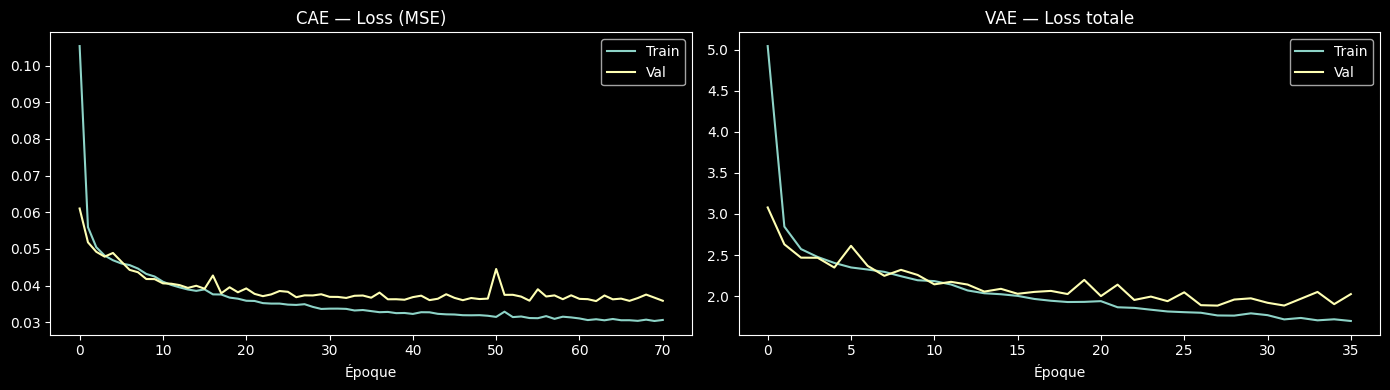

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cae.history['loss'],     label='Train')
axes[0].plot(history_cae.history['val_loss'], label='Val')
axes[0].set_title("CAE — Loss (MSE)")
axes[0].set_xlabel("Époque")
axes[0].legend()

axes[1].plot(history_vae.history['loss'],     label='Train')
axes[1].plot(history_vae.history['val_loss'], label='Val')
axes[1].set_title("VAE — Loss totale")
axes[1].set_xlabel("Époque")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Évaluation finale sur le test set

Le test set n'a jamais été vu pendant l'entraînement ni pendant la validation.
C'est ici seulement qu'on l'utilise pour la première fois.

**Correction clé :** le VAE utilise `z` échantillonné (cohérent avec l'entraînement)
et non `z_mean` directement.

In [11]:
# --- CAE ---
mse_cae = cae_model.evaluate(X_test, X_test, verbose=0)

# --- VAE — inférence avec z échantillonné (cohérent avec l'entraînement) ---
zm_test, zv_test = vae_enc.predict(X_test, verbose=0)
z_test   = zm_test + 0.1 * np.exp(0.5 * zv_test) * np.random.normal(size=zm_test.shape)
recon_vae_test = vae_dec.predict(z_test, verbose=0)
mse_vae  = np.mean(np.square(X_test - recon_vae_test))

print("=" * 45)
print(f"RÉSULTATS FINAUX  (Test set : {len(X_test)} fenêtres)")
print("=" * 45)
print(f"CAE  →  Temps : {time_cae:.1f}s  |  MSE test : {mse_cae:.6f}")
print(f"VAE  →  Temps : {time_vae:.1f}s  |  MSE test : {mse_vae:.6f}")

RÉSULTATS FINAUX  (Test set : 21104 fenêtres)
CAE  →  Temps : 939.0s  |  MSE test : 0.037172
VAE  →  Temps : 268.2s  |  MSE test : 0.038275


## 8. t-SNE sur l'espace latent (test set)

Les labels colorient les points mais n'ont jamais servi à l'entraînement.
Si les clusters correspondent aux activités, le modèle a appris une bonne
représentation de façon non supervisée.

Calcul t-SNE...


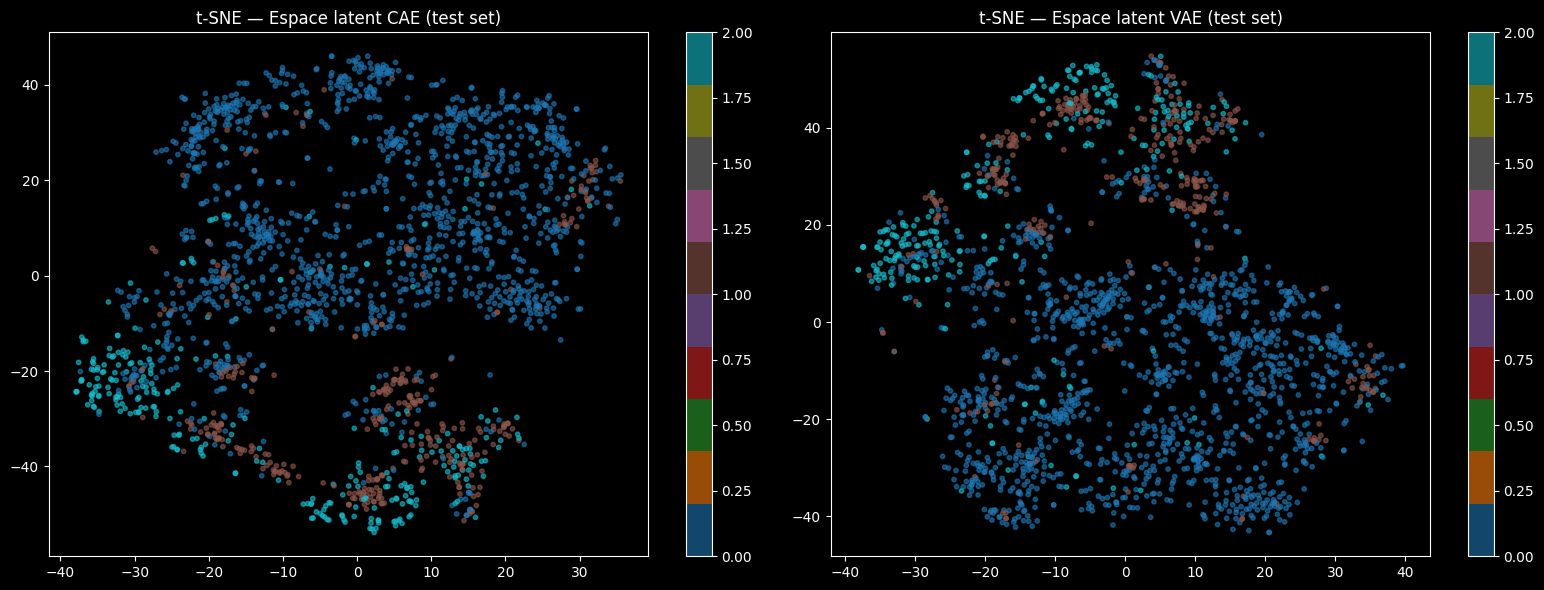

In [12]:
print("Calcul t-SNE...")
n_tsne = min(2000, len(X_test))

lat_cae      = cae_encoder.predict(X_test[:n_tsne], verbose=0)
lat_vae, _   = vae_enc.predict(X_test[:n_tsne], verbose=0)   # z_mean pour t-SNE (déterministe)

tsne    = TSNE(n_components=2, random_state=42, perplexity=30)
emb_cae = tsne.fit_transform(lat_cae)
emb_vae = tsne.fit_transform(lat_vae)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc1 = ax1.scatter(emb_cae[:, 0], emb_cae[:, 1],
                  c=y_test[:n_tsne], cmap='tab10', s=10, alpha=0.6)
ax1.set_title("t-SNE — Espace latent CAE (test set)")
plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(emb_vae[:, 0], emb_vae[:, 1],
                  c=y_test[:n_tsne], cmap='tab10', s=10, alpha=0.6)
ax2.set_title("t-SNE — Espace latent VAE (test set)")
plt.colorbar(sc2, ax=ax2)

plt.tight_layout()
plt.show()

## 9. Reconstruction cohérente — 1 minute d'une seule activité

**Correction clé :** on filtre le test set par label avant de sélectionner
les 30 fenêtres. On affiche les 3 axes séparément.

→ Change `TARGET_LABEL` et `LABEL_NAME` selon ton dataset.

Fenêtres 'Marche' disponibles dans le test set : 3454


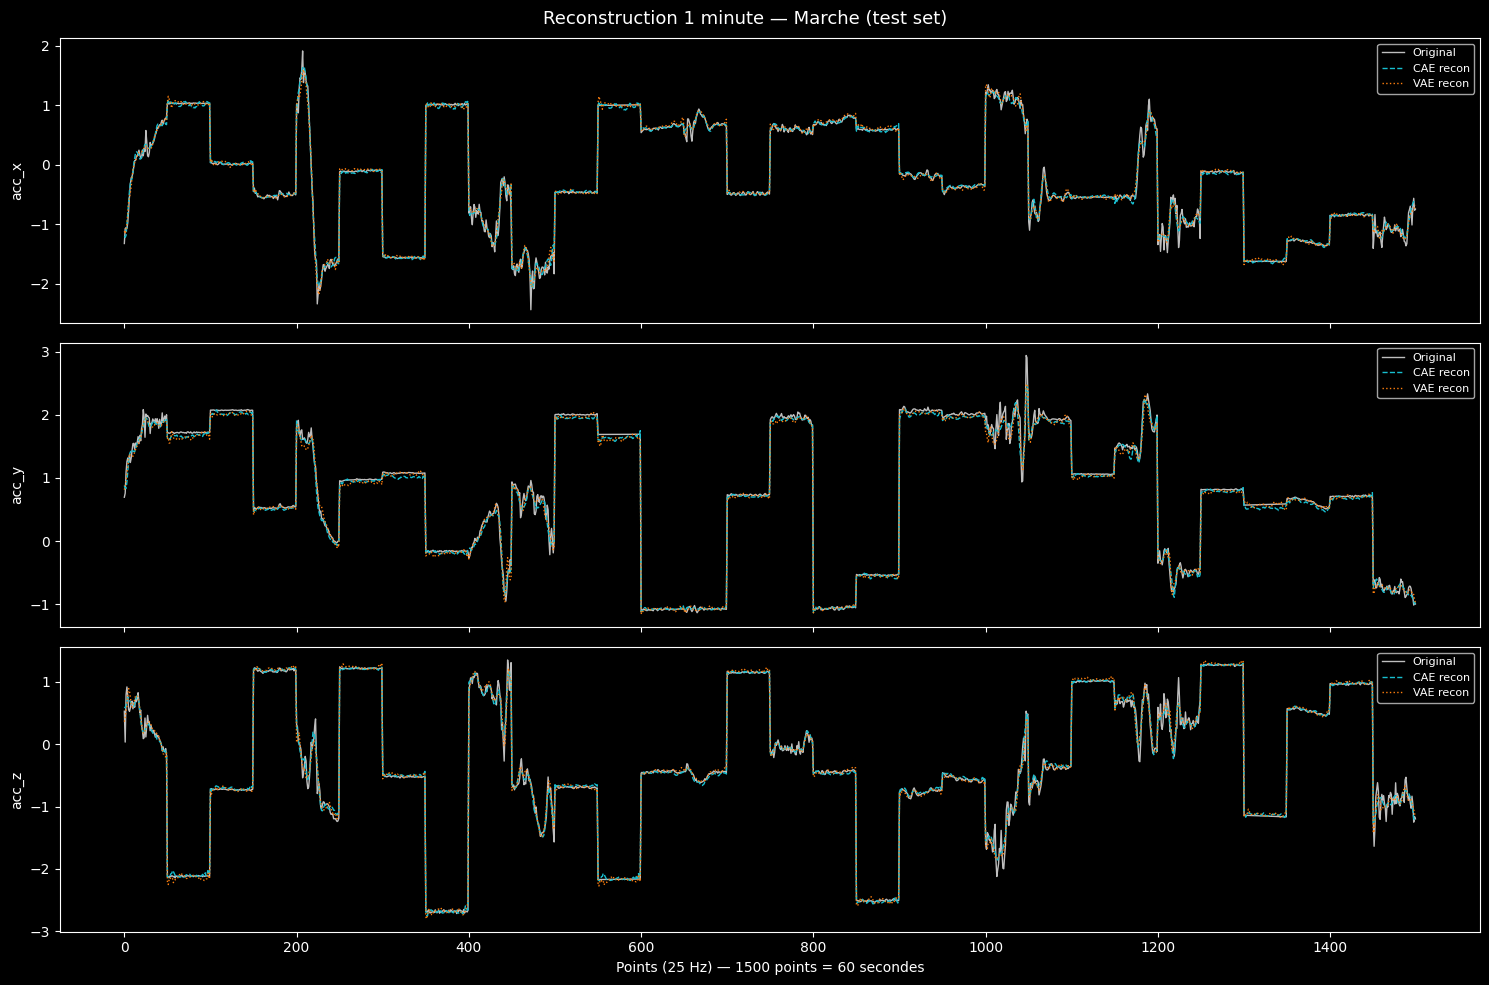

In [13]:
# ---- CELLULE 9 — Reconstruction cohérente ----

TARGET_LABEL = 1
LABEL_NAME   = "Marche"
N_WINDOWS    = 30
axis_names   = ["acc_x", "acc_y", "acc_z"]

idx_label = np.where(y_test == TARGET_LABEL)[0]
print(f"Fenêtres '{LABEL_NAME}' disponibles dans le test set : {len(idx_label)}")

segment = X_test[idx_label[:N_WINDOWS]]

recon_cae_seg = cae_model.predict(segment, verbose=0)

zm_seg, zv_seg = vae_enc.predict(segment, verbose=0)
z_seg          = zm_seg + 0.1 * np.exp(0.5 * zv_seg) * np.random.normal(size=zm_seg.shape)
recon_vae_seg  = vae_dec.predict(z_seg, verbose=0)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Reconstruction 1 minute — {LABEL_NAME} (test set)", fontsize=13)

for j, ax in enumerate(axes):
    orig  = segment[:, :, j].flatten()
    r_cae = recon_cae_seg[:, :, j].flatten()
    r_vae = recon_vae_seg[:, :, j].flatten()

    ax.plot(orig,  label="Original",  color='white', alpha=0.75, linewidth=1)
    ax.plot(r_cae, label="CAE recon", color='tab:cyan',   linestyle='--', linewidth=1)
    ax.plot(r_vae, label="VAE recon", color='tab:orange', linestyle=':',  linewidth=1)
    ax.set_ylabel(axis_names[j])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Points (25 Hz) — 1500 points = 60 secondes")
plt.tight_layout()
plt.show()

## 10. (Bonus VAE) Génération d'une minute de signal synthétique

Uniquement possible avec le VAE : on échantillonne directement dans
la zone de l'espace latent correspondant à l'activité cible,
sans avoir besoin de signal d'entrée réel.

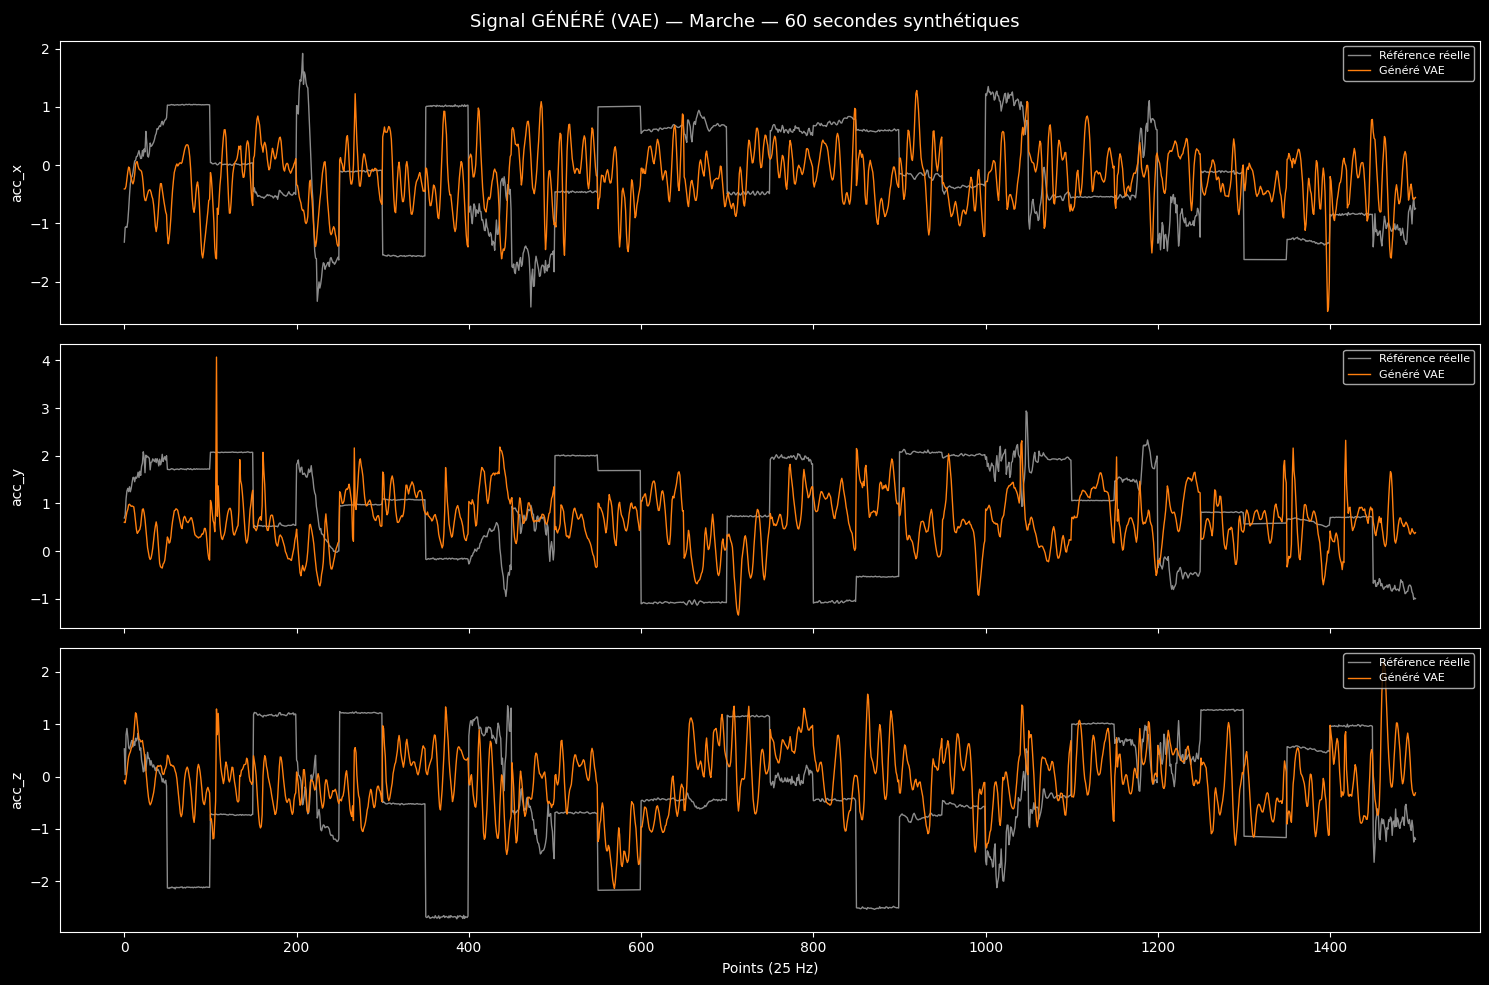

In [14]:
# ---- CELLULE 10 — Génération synthétique VAE ----

zm_label, _ = vae_enc.predict(segment, verbose=0)
z_centre     = np.mean(zm_label, axis=0)
z_std_label  = np.std(zm_label,  axis=0)

z_generated   = np.random.normal(loc=z_centre, scale=z_std_label, size=(N_WINDOWS, latent_dim))
signal_genere = vae_dec.predict(z_generated.astype(np.float32), verbose=0)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Signal GÉNÉRÉ (VAE) — {LABEL_NAME} — 60 secondes synthétiques", fontsize=13)

for j, ax in enumerate(axes):
    orig = segment[:, :, j].flatten()
    gen  = signal_genere[:, :, j].flatten()
    ax.plot(orig, label="Référence réelle", color='white',      alpha=0.55, linewidth=1)
    ax.plot(gen,  label="Généré VAE",       color='tab:orange', linewidth=1)
    ax.set_ylabel(axis_names[j])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Points (25 Hz)")
plt.tight_layout()
plt.show()